In [2]:
## IMPORTS 
import os
import sys 
LOCSCALE_2_SCRIPTS_PATH = "/home/abharadwaj1/papers/publications/2025_LocScale-2.0"
PLOT_DATA_STORE_PATH = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data"
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import pickle
import pandas as pd
from scripts.utils.plot_utils import pretty_plot_radial_profile, temporary_rcparams, configure_plot_scaling
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist

random.seed(42)
np.random.seed(42)

## Figure 2 c


In [3]:
filepath = os.path.join(PLOT_DATA_STORE_PATH, "figure_2c_radial_profiles_8702_iterations.csv")
data = pd.read_csv(filepath, index_col=0)

Text(0, 0.5, 'Log Amplitude')

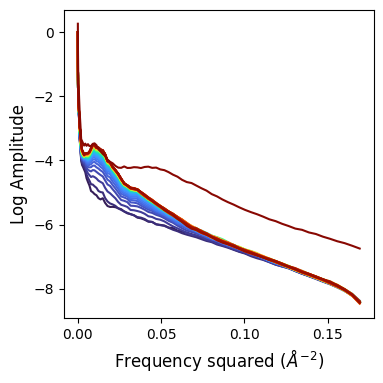

In [4]:
# Plot
import seaborn as sns
fig, ax = plt.subplots(figsize=(4,4))
sns.lineplot(data=data, x="squared_frequency", y="log_amplitudes", \
             hue="Label", palette="turbo", legend=False, ax=ax)
ax.set_xlabel("Frequency squared ($\AA^{-2}$)", fontsize=12)
ax.set_ylabel("Log Amplitude", fontsize=12)


## Figure 2 e

In [5]:
num_iterations = 30
filepath_fsc = os.path.join(PLOT_DATA_STORE_PATH, "figure_2e_fsc_8702_iterations.csv")
data_fsc_df = pd.read_csv(filepath_fsc, index_col=0)


Text(0, 0.5, 'FSC Halfmap 2')

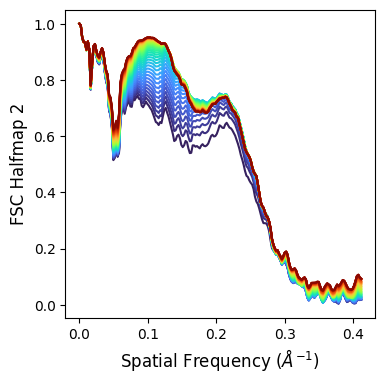

In [6]:
fig, ax = plt.subplots(figsize=(4,4))
sns.lineplot(data=data_fsc_df, x="Frequency", y="FSC Halfmap 2",\
             hue="Label", palette="turbo", legend=False, ax=ax)
ax.set_xlabel("Spatial Frequency ($\AA^{-1}$)", fontsize=12)
ax.set_ylabel("FSC Halfmap 2", fontsize=12)

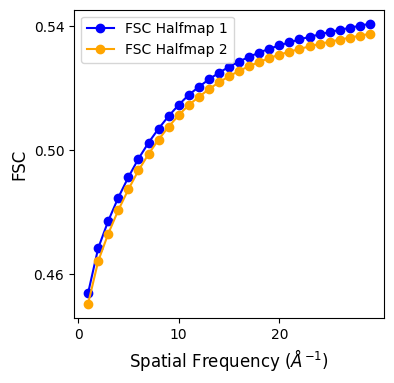

In [7]:
# plot average fsc with iteration

fsc_average_cycles_halfmap_1 = [data_fsc_df[data_fsc_df["Label"]==f"iteration {i}"]["FSC Halfmap 1"].mean() for i in range(num_iterations)]
fsc_average_cycles_halfmap_2 = [data_fsc_df[data_fsc_df["Label"]==f"iteration {i}"]["FSC Halfmap 2"].mean() for i in range(num_iterations)]
cycles = np.arange(num_iterations)
fig, ax = plt.subplots(figsize=(4,4))

ax.plot(cycles, fsc_average_cycles_halfmap_1, label="FSC Halfmap 1", color='blue',marker='o')
ax.plot(cycles, fsc_average_cycles_halfmap_2, label="FSC Halfmap 2", color='orange',marker='o')
ax.set_xlabel("Spatial Frequency ($\AA^{-1}$)", fontsize=12)
ax.set_ylabel("FSC", fontsize=12)
xticks = [0, 10, 20]
yticks = [0.46, 0.5, 0.54]
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.legend()

## Figure 2 f & Figure 2 g

In [8]:
file_save_path_bfactor_correlation = os.path.join(PLOT_DATA_STORE_PATH, "figure_2f_2g_bfactor_correlation.csv")
bfactor_correlations_data = pd.read_csv(file_save_path_bfactor_correlation, index_col=0)


In [9]:
from locscale.include.emmer.pdb.pdb_utils import get_lower_bound_threshold
emd_8702_pseudo_bfactors = bfactor_correlations_data[bfactor_correlations_data["EMDB ID"]=="8702_5vkq"]["Pseudo B-factor"]
emd_8702_atomic_bfactors = bfactor_correlations_data[bfactor_correlations_data["EMDB ID"]=="8702_5vkq"]["Atomic B-factor"]
lower_bound_threshold_pseudo = get_lower_bound_threshold(emd_8702_pseudo_bfactors, probability_threshold=0.01)
lower_bound_threshold_atomic = get_lower_bound_threshold(emd_8702_atomic_bfactors, probability_threshold=0.01)
x_array = emd_8702_pseudo_bfactors - lower_bound_threshold_pseudo
y_array = emd_8702_atomic_bfactors - lower_bound_threshold_atomic

### The Figure 2 f was generated by randomly sampling points from the pseudo-atomic model and the atomic model and thus the resulting scatter plot has a different distribution of points from the plot in the main manuscript. The correlation coefficient is however similar.

<Figure size 1181.1x1181.1 with 0 Axes>

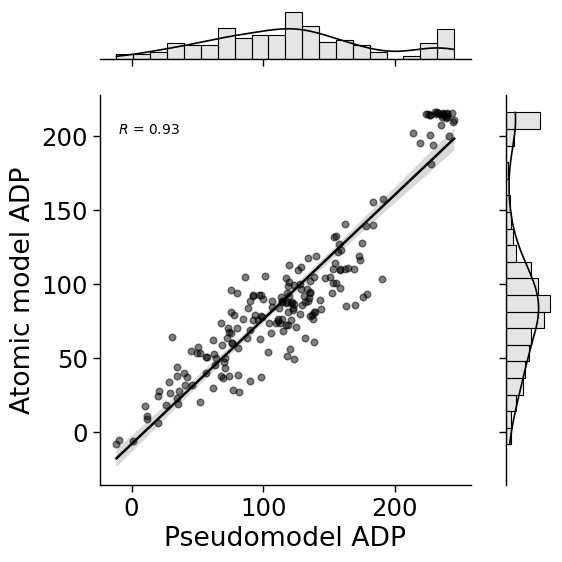

In [10]:
from scripts.utils.plot_utils import get_2d_jointplot_with_text

get_2d_jointplot_with_text(x_array, y_array, \
            "Pseudomodel ADP", "Atomic model ADP", \
            figsize_mm=(50,50), save_path=None)

Text(0.1, 0.9, 'N=83')

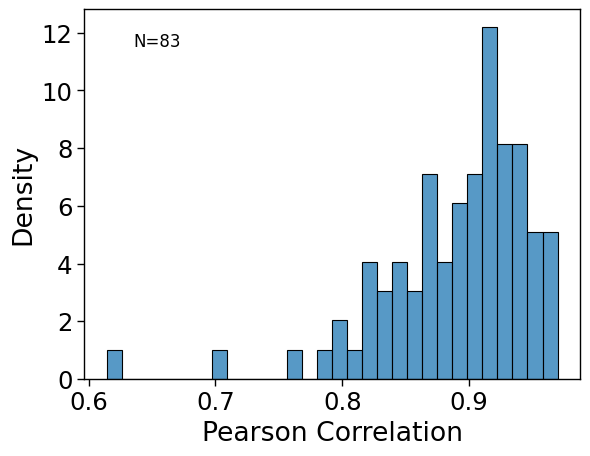

In [11]:
sns.histplot(bfactor_correlations_data["Pearson Correlation"], bins=30, stat="density")
num_emdb = len(bfactor_correlations_data["EMDB ID"].unique())
plot_text = f"N={num_emdb}"
plt.text(0.1, 0.9, plot_text, transform=plt.gca().transAxes, fontsize=12)

## Figure 2 h

In [12]:
fsc_curve_data_path = os.path.join(PLOT_DATA_STORE_PATH, "figure_2h_fsc_curves_emdb_pdb.csv")
fsc_curve_data_long = pd.read_csv(fsc_curve_data_path, index_col=0)

<Axes: xlabel='Frequency', ylabel='FSC'>

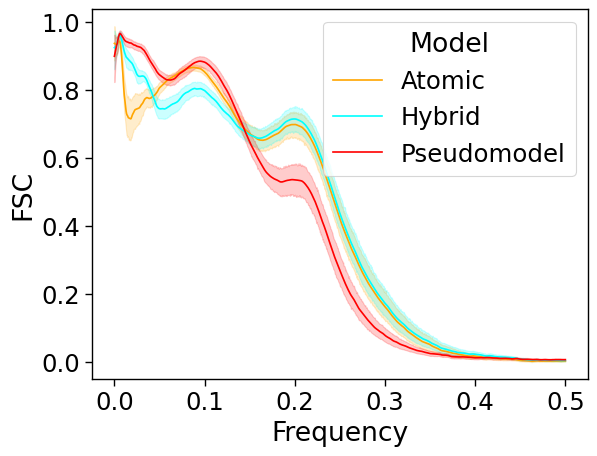

In [13]:
custom_pallette = {"Atomic": "orange", "Hybrid": "cyan", "Pseudomodel": "red"}
sns.lineplot(data=fsc_curve_data_long, x="Frequency", y="FSC", hue="Model", errorbar=('ci', 95), palette=custom_pallette)